# RESULTS ANALYSIS

/tmp/ipykernel_7279/1434116958.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Cityscapes (ID)", "COCO (OOD)"])


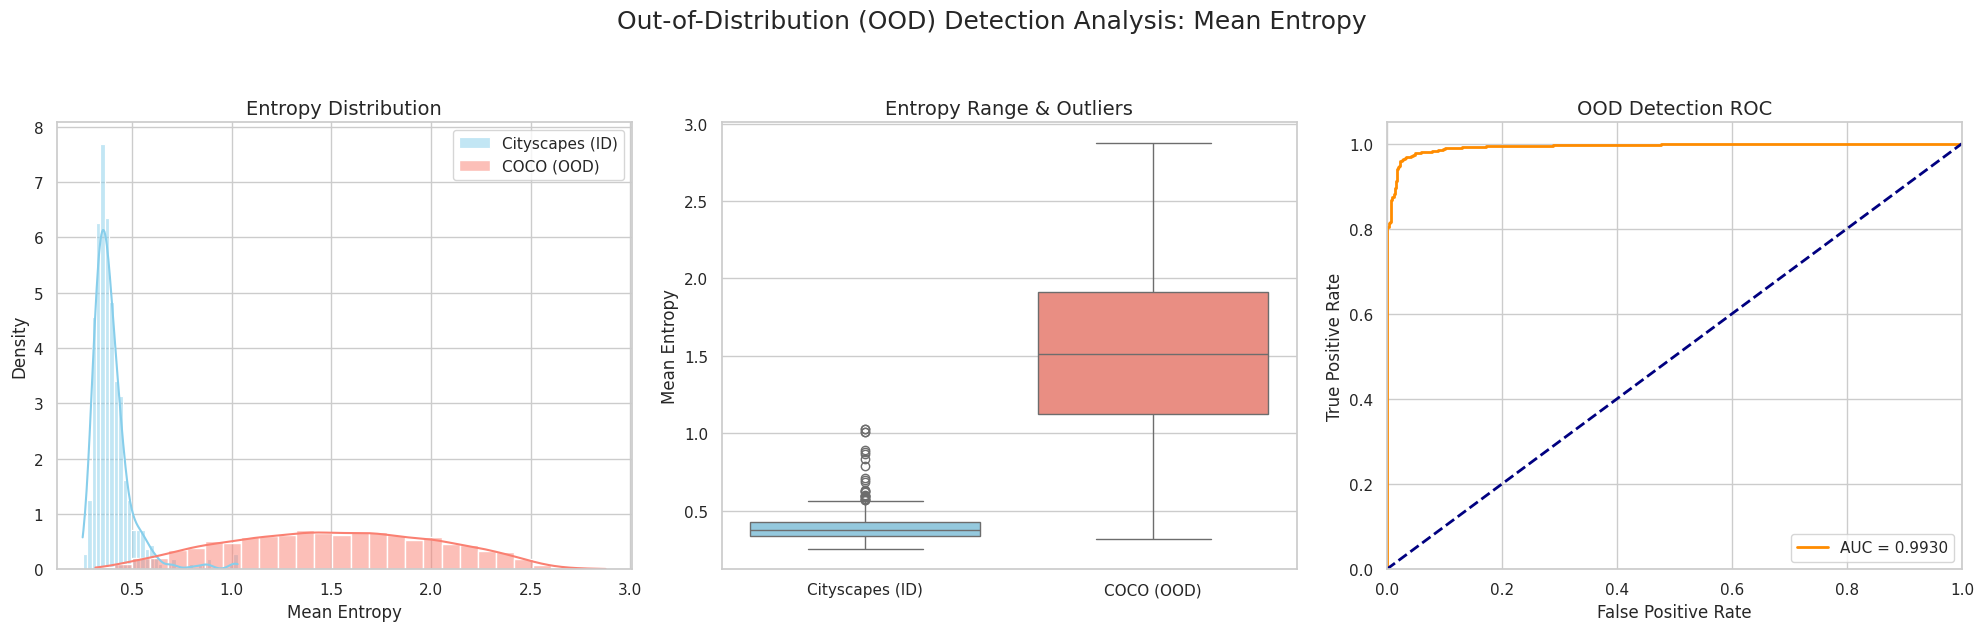

Suggested Entropy Threshold: 0.6290
At this threshold: True Positive Rate = 0.9626, False Positive Rate = 0.0258


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from pathlib import Path

DATA_FILE = "/content/entropy_data.npz"


data = np.load(DATA_FILE)
ood_scores, ood_dist = data['id_entropy'], data['id_dist']
id_scores, id_dist = data['ood_entropy'], data['ood_dist']

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# PLOT ENTROPY INFORMATION
sns.histplot(id_scores, kde=True, color="skyblue", label="Cityscapes (ID)",
              stat="density", alpha=0.5, ax=axes[0])
sns.histplot(ood_scores, kde=True, color="salmon", label="COCO (OOD)",
              stat="density", alpha=0.5, ax=axes[0])
axes[0].set_title("Entropy Distribution", fontsize=14)
axes[0].set_xlabel("Mean Entropy")
axes[0].legend()

sns.boxplot(data=[id_scores, ood_scores], palette=["skyblue", "salmon"], ax=axes[1])
axes[1].set_xticklabels(["Cityscapes (ID)", "COCO (OOD)"])
axes[1].set_title("Entropy Range & Outliers", fontsize=14)
axes[1].set_ylabel("Mean Entropy")

y_true = np.concatenate([np.zeros(len(id_scores)), np.ones(len(ood_scores))])
y_scores = np.concatenate([id_scores, ood_scores])
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('OOD Detection ROC', fontsize=14)
axes[2].legend(loc="lower right")

plt.suptitle("Out-of-Distribution (OOD) Detection Analysis: Mean Entropy", fontsize=18, y=1.05)
plt.tight_layout()

plt.savefig("ood_analysis_combined.png", bbox_inches='tight')
plt.show()

# Calculate and print the "Optimal" Threshold (Youden's J statistic)
idx = np.argmax(tpr - fpr)
best_threshold = thresholds[idx]
print(f"Suggested Entropy Threshold: {best_threshold:.4f}")
print(f"At this threshold: True Positive Rate = {tpr[idx]:.4f}, False Positive Rate = {fpr[idx]:.4f}")

/tmp/ipykernel_7279/1847260810.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Cityscapes (ID)", "COCO (OOD)"])


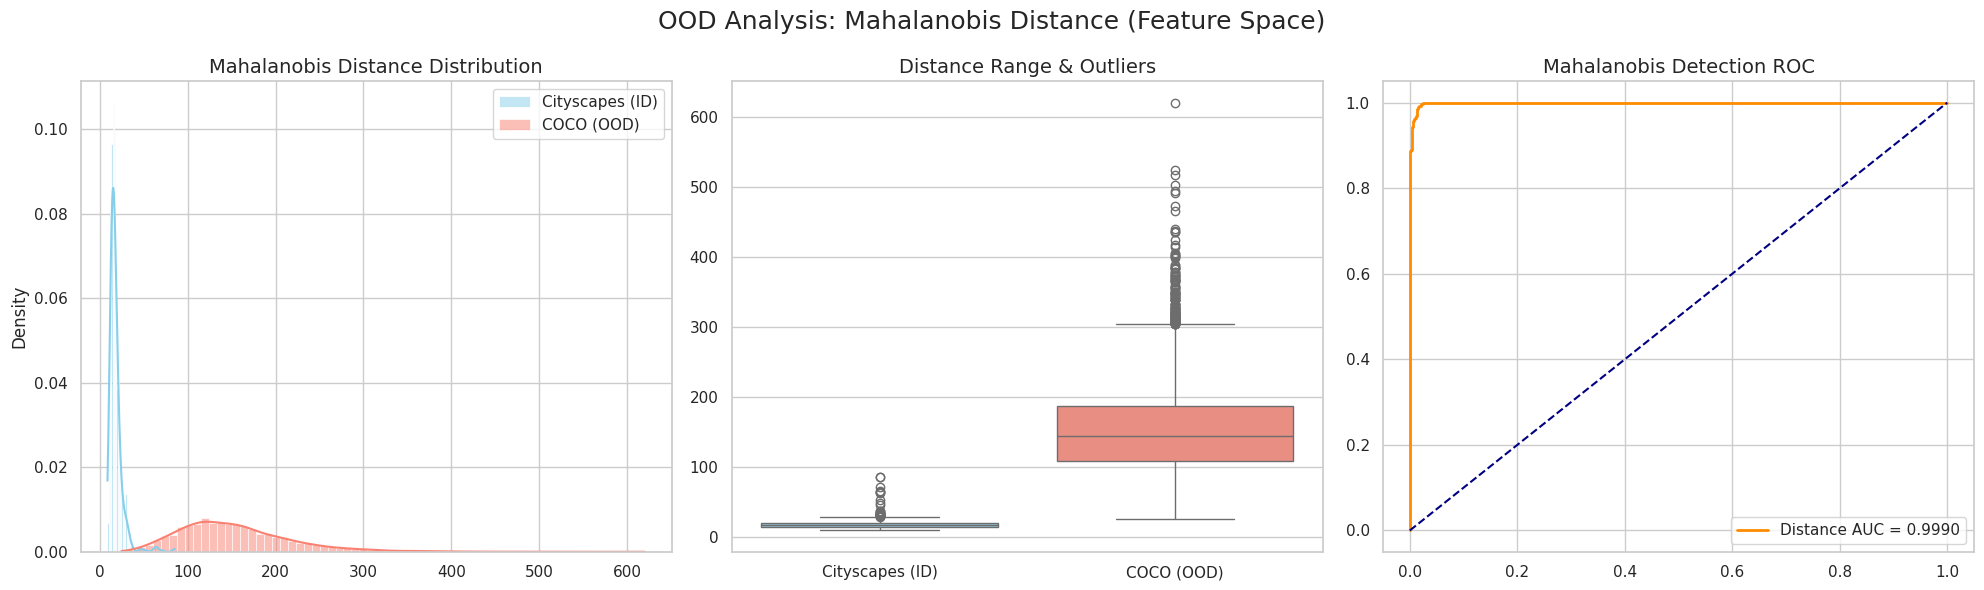

Suggested Mahalanobis Distance Threshold: 0.8313
At this threshold: True Positive Rate = 0.9972, False Positive Rate = 0.0199


In [15]:
# PLOT MAHALANOBIS DISTANCE INFORMATION

sns.set_theme(style="whitegrid")

fig1, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.histplot(id_dist, kde=True, color="skyblue", label="Cityscapes (ID)", stat="density", ax=axes[0])
sns.histplot(ood_dist, kde=True, color="salmon", label="COCO (OOD)", stat="density", ax=axes[0])
axes[0].set_title("Mahalanobis Distance Distribution", fontsize=14)
axes[0].legend()

# Boxplot
sns.boxplot(data=[id_dist, ood_dist], palette=["skyblue", "salmon"], ax=axes[1])
axes[1].set_xticklabels(["Cityscapes (ID)", "COCO (OOD)"])
axes[1].set_title("Distance Range & Outliers", fontsize=14)

# ROC Curve
y_true = np.concatenate([np.zeros(len(id_dist)), np.ones(len(ood_dist))])
y_scores = np.concatenate([id_dist, ood_dist])
fpr, tpr, _ = roc_curve(y_true, y_scores)
axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'Distance AUC = {auc(fpr, tpr):.4f}')
axes[2].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[2].set_title("Mahalanobis Detection ROC", fontsize=14)
axes[2].legend(loc="lower right")

plt.suptitle("OOD Analysis: Mahalanobis Distance (Feature Space)", fontsize=18)
plt.tight_layout()
plt.show()
# Calculate and print the "Optimal" Threshold (Youden's J statistic)
idx = np.argmax(tpr - fpr)
best_threshold = thresholds[idx]
print(f"Suggested Mahalanobis Distance Threshold: {best_threshold:.4f}")
print(f"At this threshold: True Positive Rate = {tpr[idx]:.4f}, False Positive Rate = {fpr[idx]:.4f}")

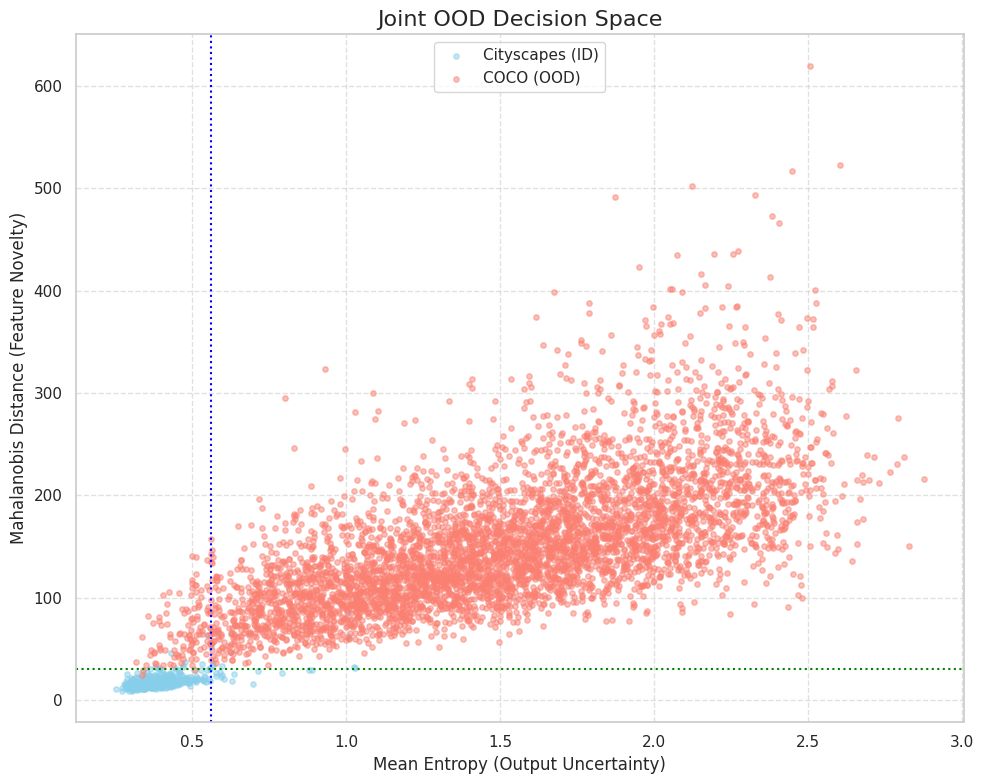

In [16]:
plt.figure(figsize=(10, 8))

# Plot ID points
plt.scatter(id_scores, id_dist, color='skyblue', alpha=0.5, s=15, label='Cityscapes (ID)')
# Plot OOD points
plt.scatter(ood_scores, ood_dist, color='salmon', alpha=0.5, s=15, label='COCO (OOD)')

plt.xlabel("Mean Entropy (Output Uncertainty)")
plt.ylabel("Mahalanobis Distance (Feature Novelty)")
plt.title("Joint OOD Decision Space", fontsize=16)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.axvline(x=np.percentile(id_scores, 95), color='blue', linestyle=':', label='95% ID Entropy')
plt.axhline(y=np.percentile(id_dist, 95), color='green', linestyle=':', label='95% ID Distance')

plt.tight_layout()
plt.savefig("joint_ood_scatter.png")
plt.show()

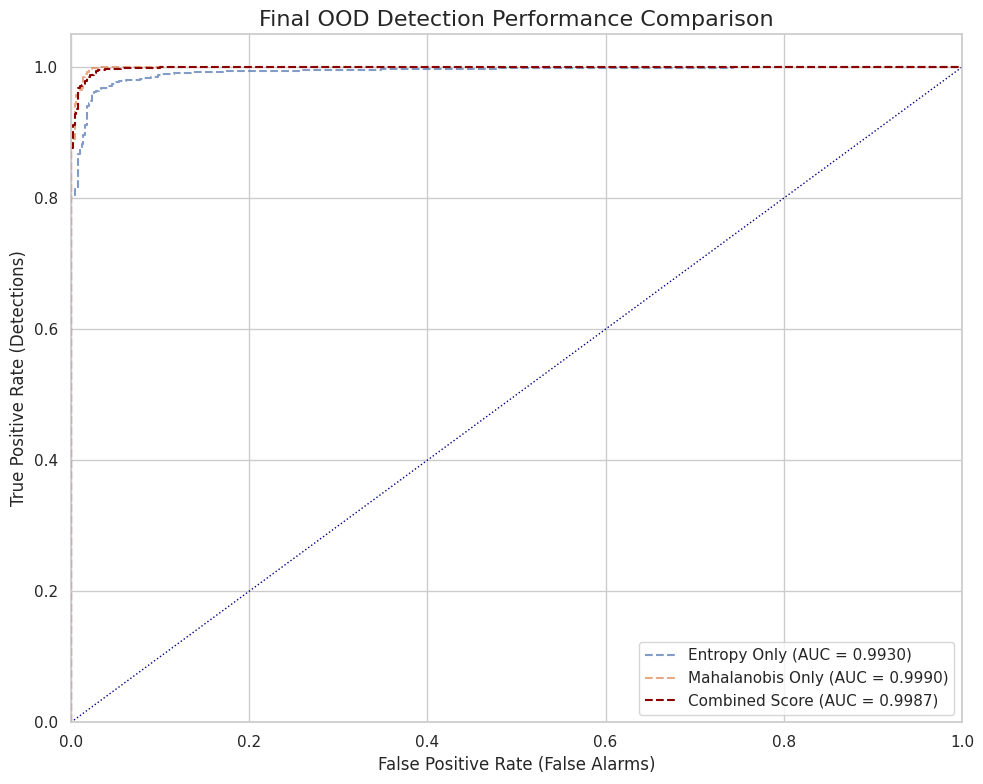

Improvement over Entropy: 0.005661


In [17]:
id_ent_mean = np.mean(id_scores)
id_ent_std = np.std(id_scores)

id_dist_mean = np.mean(id_dist)
id_dist_std = np.std(id_dist)

#Normalize ID data (will now have Mean=0, Std=1)
id_z_ent = (id_scores - id_ent_mean) / id_ent_std
id_z_dist = (id_dist - id_dist_mean) / id_dist_std

# Normalize OOD data using the ID baseline
ood_z_ent = (ood_scores - id_ent_mean) / id_ent_std
ood_z_dist = (ood_dist - id_dist_mean) / id_dist_std

#Combine
id_combined = id_z_ent + id_z_dist
ood_combined = ood_z_ent + ood_z_dist

def get_roc_data(id_scores, ood_scores):
    y_true = np.concatenate([np.zeros(len(id_scores)), np.ones(len(ood_scores))])
    y_scores = np.concatenate([id_scores, ood_scores])
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    return fpr, tpr, auc(fpr, tpr)

fpr_e, tpr_e, auc_e = get_roc_data(id_scores, ood_scores)
fpr_d, tpr_d, auc_d = get_roc_data(id_dist, ood_dist)
fpr_c, tpr_c, auc_c = get_roc_data(id_combined, ood_combined)

# --- Visualization ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))

plt.plot(fpr_e, tpr_e, label=f'Entropy Only (AUC = {auc_e:.4f})', linestyle='--', alpha=0.7)
plt.plot(fpr_d, tpr_d, label=f'Mahalanobis Only (AUC = {auc_d:.4f})', linestyle='--', alpha=0.7)
plt.plot(fpr_c, tpr_c, label=f'Combined Score (AUC = {auc_c:.4f})', linestyle='--', color='darkred')

plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle=':')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Detections)')
plt.title('Final OOD Detection Performance Comparison', fontsize=16)
plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig("final_ood_comparison.png")
plt.show()

print(f"Improvement over Entropy: {auc_c - auc_e:.6f}")

# ANALYSIS MODEL TRAINING

/tmp/ipykernel_7279/2772051740.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Cityscapes (ID)", "COCO (OOD)"])


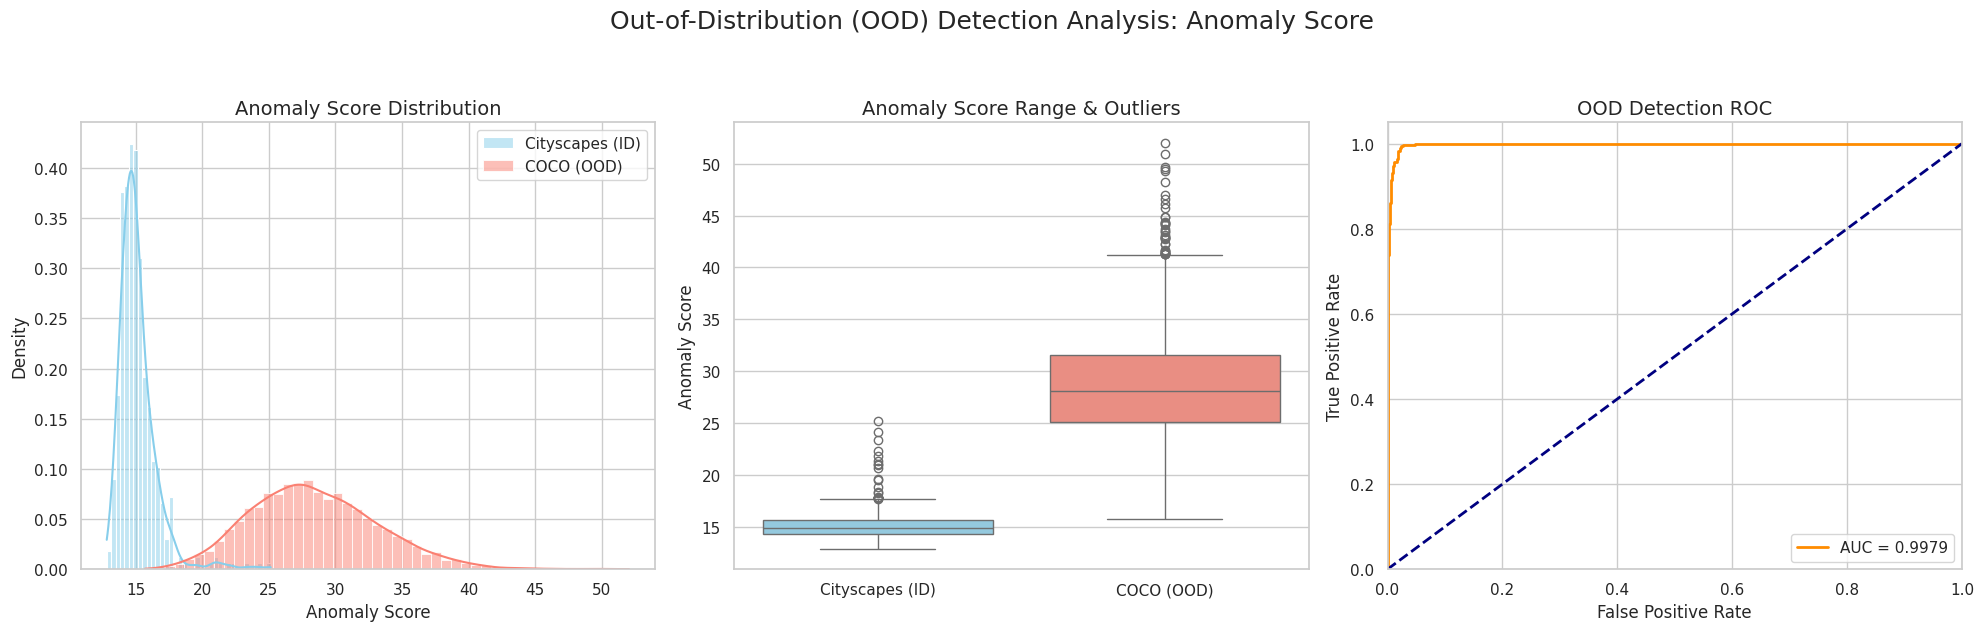

Suggested Anomaly Score Threshold: 18.3471
At this threshold: True Positive Rate = 0.9940, False Positive Rate = 0.0239


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from pathlib import Path

id_scores_model = np.load("id_scores.npy")
ood_scores_model = np.load("ood_scores.npy")

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# PLOT ENTROPY INFORMATION
sns.histplot(id_scores_model, kde=True, color="skyblue", label="Cityscapes (ID)",
              stat="density", alpha=0.5, ax=axes[0])
sns.histplot(ood_scores_model, kde=True, color="salmon", label="COCO (OOD)",
              stat="density", alpha=0.5, ax=axes[0])
axes[0].set_title("Anomaly Score Distribution", fontsize=14)
axes[0].set_xlabel("Anomaly Score")
axes[0].legend()

sns.boxplot(data=[id_scores_model, ood_scores_model], palette=["skyblue", "salmon"], ax=axes[1])
axes[1].set_xticklabels(["Cityscapes (ID)", "COCO (OOD)"])
axes[1].set_title("Anomaly Score Range & Outliers", fontsize=14)
axes[1].set_ylabel("Anomaly Score")

y_true = np.concatenate([np.zeros(len(id_scores_model)), np.ones(len(ood_scores_model))])
y_scores = np.concatenate([id_scores_model, ood_scores_model])
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('OOD Detection ROC', fontsize=14)
axes[2].legend(loc="lower right")

plt.suptitle("Out-of-Distribution (OOD) Detection Analysis: Anomaly Score", fontsize=18, y=1.05)
plt.tight_layout()

plt.savefig("ood_analysis_combined.png", bbox_inches='tight')
plt.show()

# Calculate and print the "Optimal" Threshold (Youden's J statistic)
idx = np.argmax(tpr - fpr)
best_threshold = thresholds[idx]
print(f"Suggested Anomaly Score Threshold: {best_threshold:.4f}")
print(f"At this threshold: True Positive Rate = {tpr[idx]:.4f}, False Positive Rate = {fpr[idx]:.4f}")

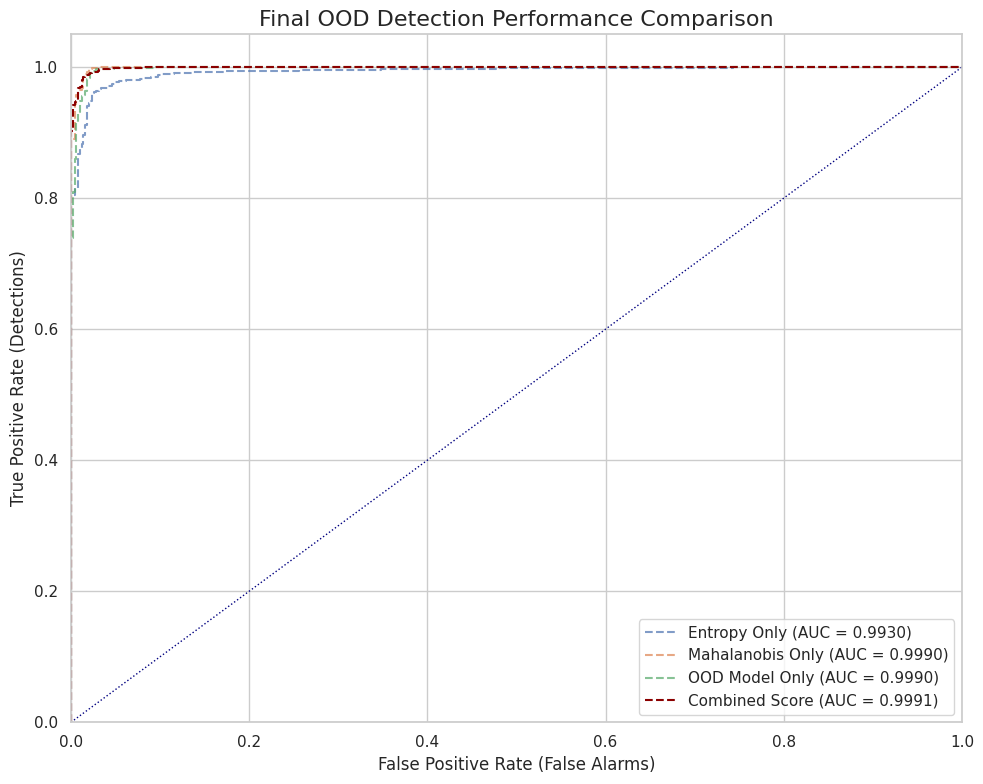

Improvement over OOD Model: 0.001142


In [19]:
id_ent_mean = np.mean(id_scores)
id_ent_std = np.std(id_scores)

id_dist_mean = np.mean(id_dist)
id_dist_std = np.std(id_dist)

id_model_mean = np.mean(id_scores_model)
id_model_std = np.std(id_scores_model)


#Normalize ID data (will now have Mean=0, Std=1)
id_z_ent = (id_scores - id_ent_mean) / id_ent_std
id_z_dist = (id_dist - id_dist_mean) / id_dist_std
id_z_model = (id_scores_model - id_model_mean) / id_model_std

# Normalize OOD data using the ID baseline
ood_z_ent = (ood_scores - id_ent_mean) / id_ent_std
ood_z_dist = (ood_dist - id_dist_mean) / id_dist_std
ood_z_model = (ood_scores_model - id_model_mean) / id_model_std

#Combine
id_combined = id_z_ent + id_z_dist + id_z_model
ood_combined = ood_z_ent + ood_z_dist + ood_z_model

def get_roc_data(id_scores, ood_scores):
    y_true = np.concatenate([np.zeros(len(id_scores)), np.ones(len(ood_scores))])
    y_scores = np.concatenate([id_scores, ood_scores])
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    return fpr, tpr, auc(fpr, tpr)

fpr_e, tpr_e, auc_e = get_roc_data(id_scores, ood_scores)
fpr_d, tpr_d, auc_d = get_roc_data(id_dist, ood_dist)
fpr_m, tpr_m, auc_m = get_roc_data(id_scores_model, ood_scores_model)
fpr_c, tpr_c, auc_c = get_roc_data(id_combined, ood_combined)

# --- Visualization ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))

plt.plot(fpr_e, tpr_e, label=f'Entropy Only (AUC = {auc_e:.4f})', linestyle='--', alpha=0.7)
plt.plot(fpr_d, tpr_d, label=f'Mahalanobis Only (AUC = {auc_d:.4f})', linestyle='--', alpha=0.7)
plt.plot(fpr_m, tpr_m, label=f'OOD Model Only (AUC = {auc_d:.4f})', linestyle='--', alpha=0.7)
plt.plot(fpr_c, tpr_c, label=f'Combined Score (AUC = {auc_c:.4f})', linestyle='--', color='darkred')

plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle=':')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Detections)')
plt.title('Final OOD Detection Performance Comparison', fontsize=16)
plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig("final_ood_comparison.png")
plt.show()

print(f"Improvement over OOD Model: {auc_c - auc_m:.6f}")

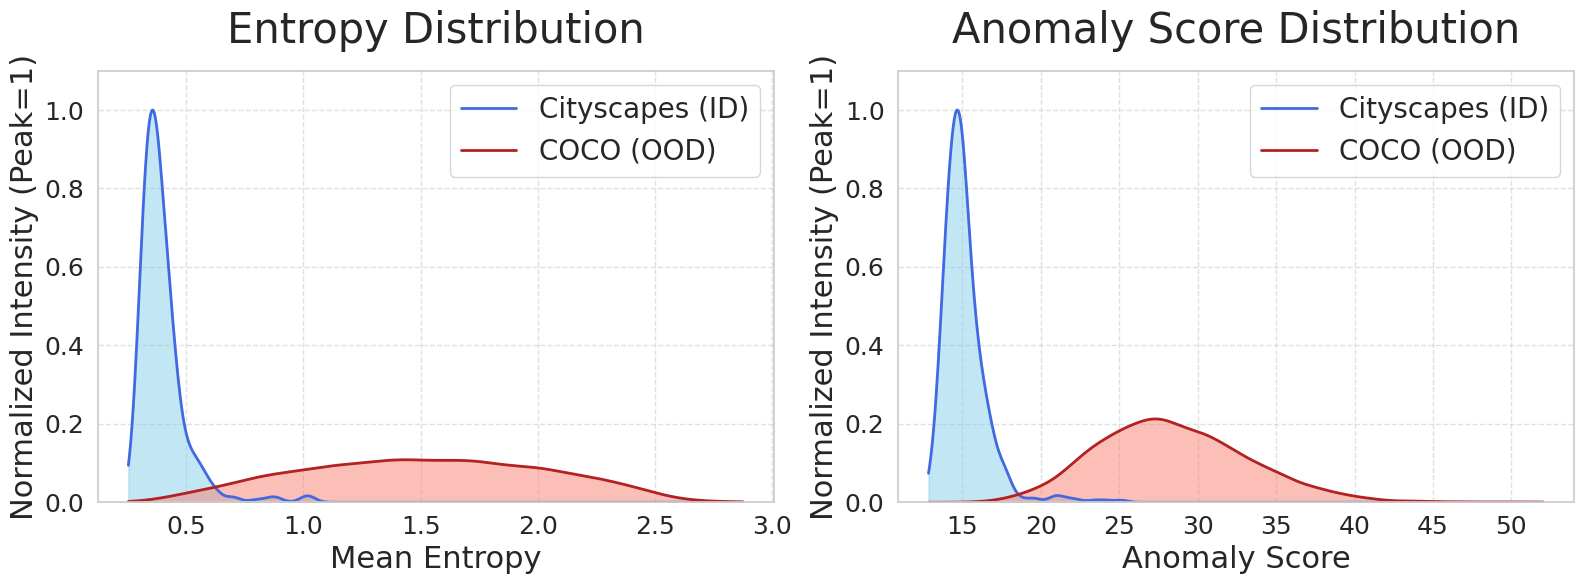

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

def plot_peak_normalized(id_data, ood_data, title, xlabel, ax):
    # 1. Compute Kernel Density Estimation (KDE) for both
    kde_id = gaussian_kde(id_data)
    kde_ood = gaussian_kde(ood_data)

    # 2. Create a range of X values for plotting
    x_min = min(id_data.min(), ood_data.min())
    x_max = max(id_data.max(), ood_data.max())
    x_range = np.linspace(x_min, x_max, 500)

    # 3. Get raw density values
    dens_id = kde_id(x_range)
    dens_ood = kde_ood(x_range)

    # 4. NORMALIZATION STEP:
    # Divide both by the peak height of the ID distribution
    peak_height = np.max(dens_id)
    dens_id_norm = dens_id / peak_height
    dens_ood_norm = dens_ood / peak_height

    # 5. Plotting
    ax.plot(x_range, dens_id_norm, color='royalblue', lw=2, label='Cityscapes (ID)')
    ax.fill_between(x_range, dens_id_norm, color='skyblue', alpha=0.5)

    ax.plot(x_range, dens_ood_norm, color='firebrick', lw=2, label='COCO (OOD)')
    ax.fill_between(x_range, dens_ood_norm, color='salmon', alpha=0.5)

    # Formatting
    ax.set_title(title, fontsize=30, pad=20)
    ax.set_xlabel(xlabel, fontsize=22)
    ax.set_ylabel("Normalized Intensity (Peak=1)", fontsize=22)
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.set_ylim(0, 1.1) # Leave a little room at the top
    ax.legend(fontsize=20, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.6)

# --- EXAMPLE USAGE ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

plot_peak_normalized(id_scores, ood_scores, "Entropy Distribution", "Mean Entropy", ax1)
plot_peak_normalized(id_scores_model,ood_scores_model, "Anomaly Score Distribution", "Anomaly Score", ax2)

plt.tight_layout()
plt.savefig('normalized_comparison.png', dpi=300)

In [21]:
import numpy as np

def compute_separation_metrics(id_scores, ood_scores):
    mu_id = np.mean(id_scores)
    mu_ood = np.mean(ood_scores)
    var_id = np.var(id_scores)
    var_ood = np.var(ood_scores)
    std_id = np.std(id_scores)
    std_ood = np.std(ood_scores)

    # 1. Fisher's Ratio
    fisher_ratio = (mu_id - mu_ood)**2 / (var_id + var_ood)

    # 2. Cohen's d
    pooled_std = np.sqrt((std_id**2 + std_ood**2) / 2)
    cohens_d = np.abs(mu_id - mu_ood) / pooled_std

    return {
        "Fisher Ratio": fisher_ratio,
        "Cohens d": cohens_d
    }

# Example use:
entropy_stats = compute_separation_metrics(id_scores, ood_scores)
anomaly_stats = compute_separation_metrics(id_scores_model, ood_scores_model)

print(f"Entropy Separation (d): {entropy_stats['Cohens d']:.2f}")
print(f"Anomaly Separation (d): {anomaly_stats['Cohens d']:.2f}")

Entropy Separation (d): 3.02
Anomaly Separation (d): 3.76


# FINAL SCORE COMPUTATION

In [22]:
def compute_final_metric(id_scores, id_dice_vals, ood_scores, threshold):
    """
    id_scores: List of OOD scores for Cityscapes (ID)
    id_dice_vals: List of actual DICE scores for Cityscapes
    ood_scores: List of OOD scores for COCO (OOD)
    threshold: The cut-off score to decide if an image is OOD
    """
    final_dice_list = []

    # Process ID Images (Cityscapes)
    for score, dice in zip(id_scores, id_dice_vals):
        if score < threshold:
            # Model correctly identifies as ID -> Keep the real DICE
            final_dice_list.append(dice)
        else:
            # Model incorrectly excludes ID image -> Penalty DICE = 0
            final_dice_list.append(0.0)

    # Process OOD Images (COCO)
    # Note: OOD images don't have a 'real' DICE because there is no ID ground truth
    #for score in ood_scores:
     #   if score < threshold:
            # Model incorrectly includes OOD image as ID -> Penalty DICE = 0
      #      final_dice_list.append(0.0)
       # else:
        #    continue

    return np.mean(final_dice_list)

id_scores_model = np.load("id_scores.npy")
ood_scores_model = np.load("ood_scores.npy")
id_dice = np.load("id_dice_scores.npy")

compute_final_metric(id_scores_model, id_dice, ood_scores_model, 18.5189)

np.float64(0.5424847230167086)

In [23]:
print(np.mean(id_dice))

0.5535979


# IMAGE SEGMENTATION

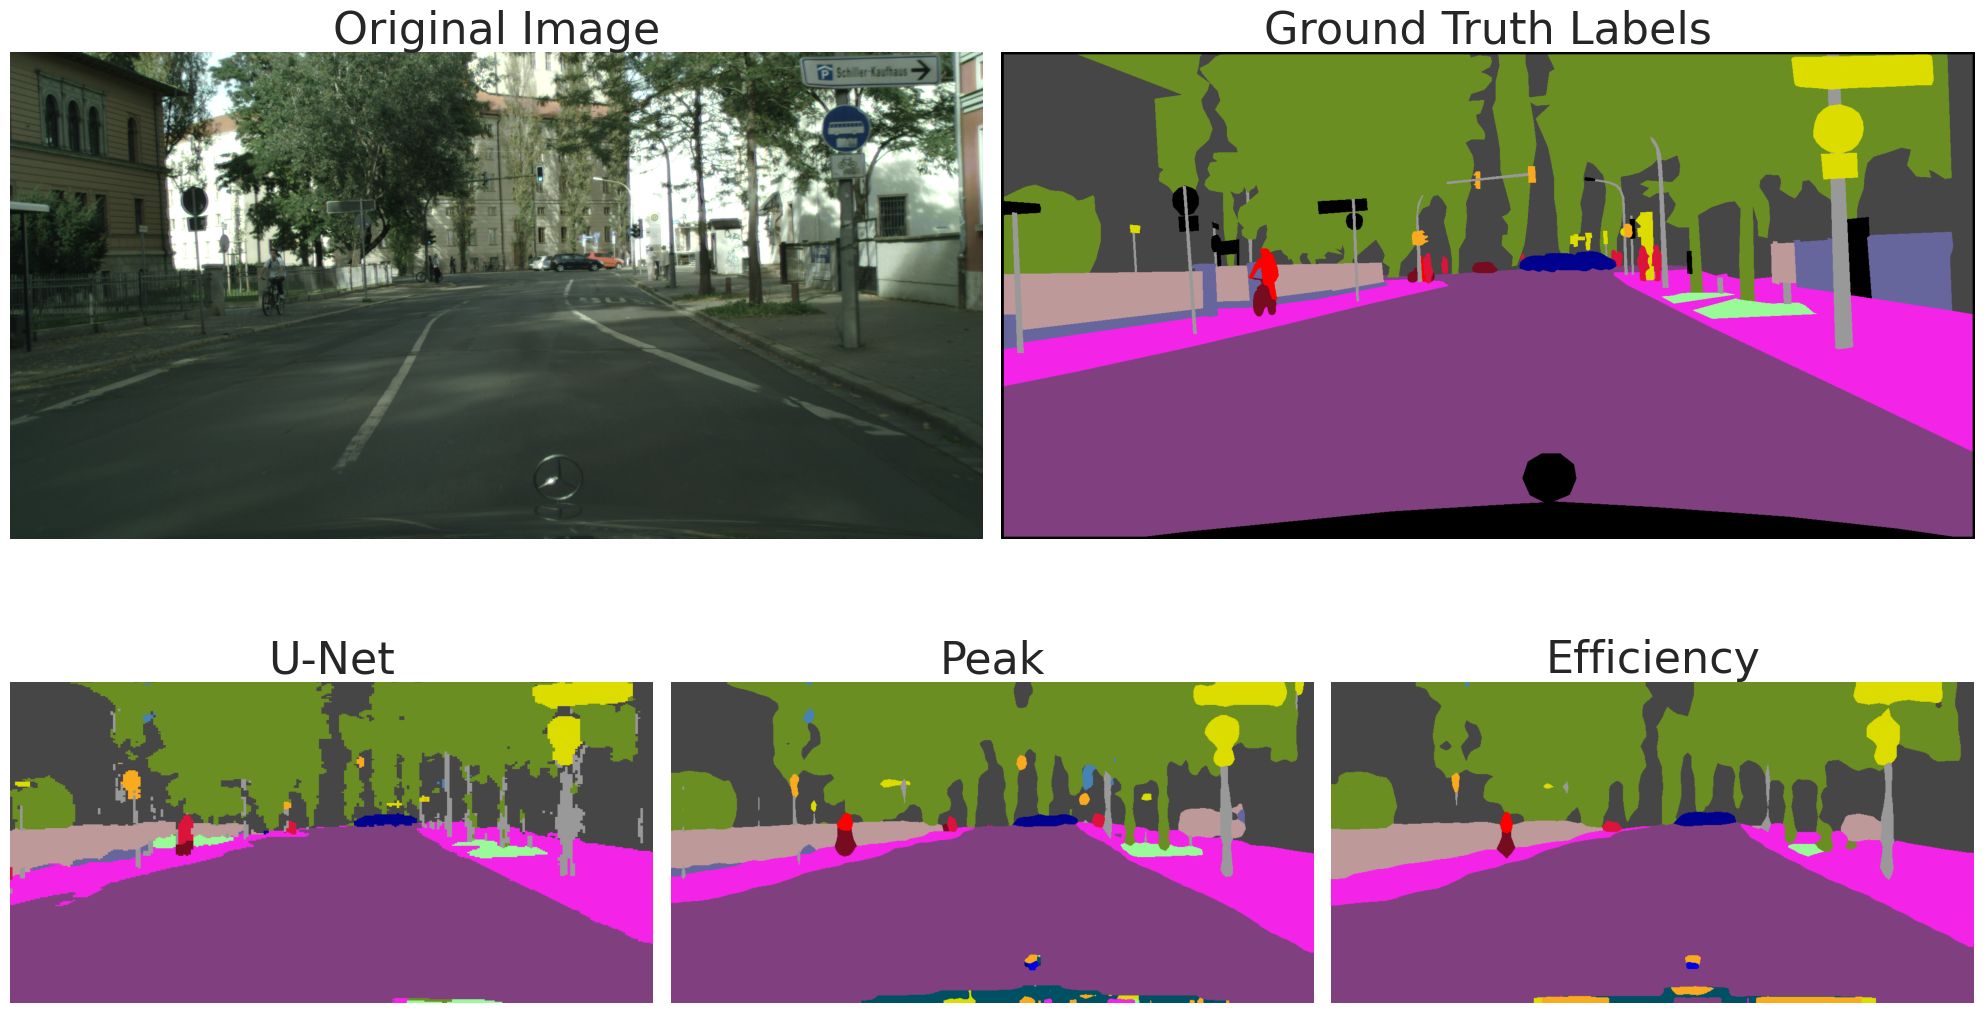

In [27]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torchvision.datasets import Cityscapes

# --- YOUR EXISTING FUNCTIONS ---
# (Assuming Cityscapes.classes is already defined in your environment)
train_id_to_color = {cls.train_id: cls.color for cls in Cityscapes.classes if cls.train_id != 255}
train_id_to_color[255] = (0, 0, 0)

def convert_train_id_to_color(prediction: torch.Tensor) -> torch.Tensor:
    # Expects shape (B, 1, H, W)
    batch, _, height, width = prediction.shape
    color_image = torch.zeros((batch, 3, height, width), dtype=torch.uint8)

    for train_id, color in train_id_to_color.items():
        mask = prediction[:, 0] == train_id
        for i in range(3):
            color_image[:, i][mask] = color[i]
    return color_image

# --- HELPER TO USE YOUR FUNCTION ON FILES ---
def process_result_file(file_path):
    # Load mask and convert to tensor (B, C, H, W)
    mask = Image.open(file_path).convert('L')
    mask_tensor = torch.from_numpy(np.array(mask)).unsqueeze(0).unsqueeze(0) # (1, 1, H, W)

    # Apply your colorization function
    color_tensor = convert_train_id_to_color(mask_tensor)

    # Convert back to (H, W, 3) for plotting
    return color_tensor.squeeze(0).permute(1, 2, 0).numpy()

# --- PLOTTING LOGIC ---
# Load original and ground truth
orig_img = Image.open('/content/weimar_000100_000019_leftImg8bit.png')
labels_img = Image.open('/content/weimar_000100_000019_gtFine_color.png')

# Process your three results using your custom function
unet_res = process_result_file('/content/u_net.png')
peak_res = process_result_file('/content/peak.png')
efficiency_res = process_result_file('/content/efficiency.png')

fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(2, 6)

# Row 1
ax1 = plt.subplot(gs[0, 0:3])
ax1.imshow(orig_img); ax1.set_title('Original Image', fontsize=32); ax1.axis('off')

ax2 = plt.subplot(gs[0, 3:6])
ax2.imshow(labels_img); ax2.set_title('Ground Truth Labels', fontsize=32); ax2.axis('off')

# Row 2 (Your colorized results)
ax3 = plt.subplot(gs[1, 0:2])
ax3.imshow(unet_res); ax3.set_title('U-Net', fontsize=32); ax3.axis('off')

ax4 = plt.subplot(gs[1, 2:4])
ax4.imshow(peak_res); ax4.set_title('Peak', fontsize=32); ax4.axis('off')

ax5 = plt.subplot(gs[1, 4:6])
ax5.imshow(efficiency_res); ax5.set_title('Efficiency', fontsize=32); ax5.axis('off')

plt.tight_layout()
plt.savefig('final_paper_comparison.png', dpi=300, bbox_inches='tight')
plt.show()